File used: /content/SuperStore_Sales_Dataset.csv
Dataset Shape: (9800, 18)

Time Series Information
-----------------------
Start Date: 2015-01-03
End Date  : 2018-12-30
Number of Days: 1458


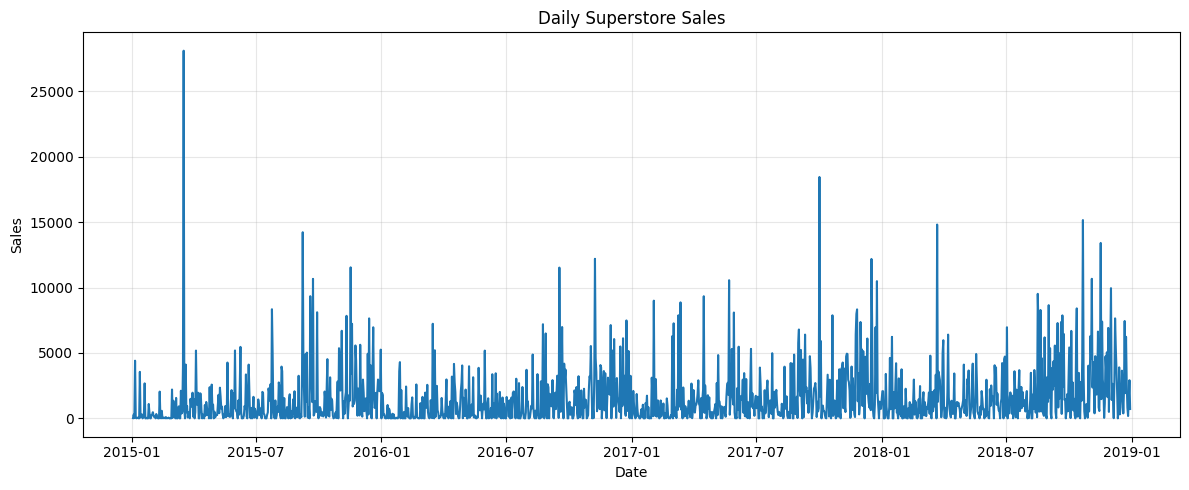


Training Days: 1451
Testing Days : 7

================ MODEL PERFORMANCE ================

               Model     MAE    RMSE
7-Day Moving Average 1632.15 2003.91
        Holt-Winters 1666.60 1833.09
Best Forecasting Model: Holt-Winters


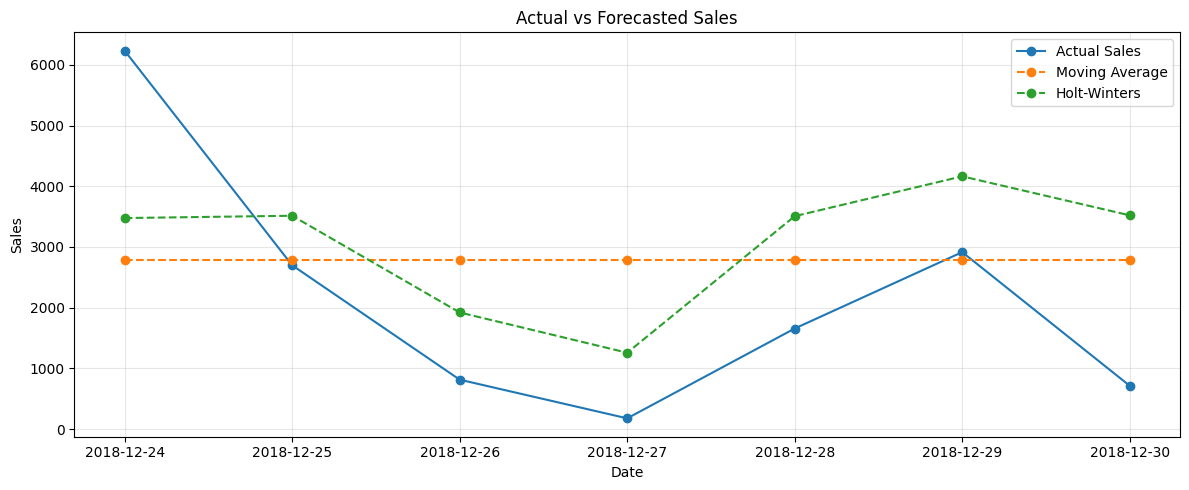


================ NEXT 7 DAYS FORECAST ================

      Date  Forecasted Sales
2018-12-31           3338.29
2019-01-01           3226.96
2019-01-02           1623.37
2019-01-03            963.17
2019-01-04           3184.18
2019-01-05           3867.98
2019-01-06           3203.82


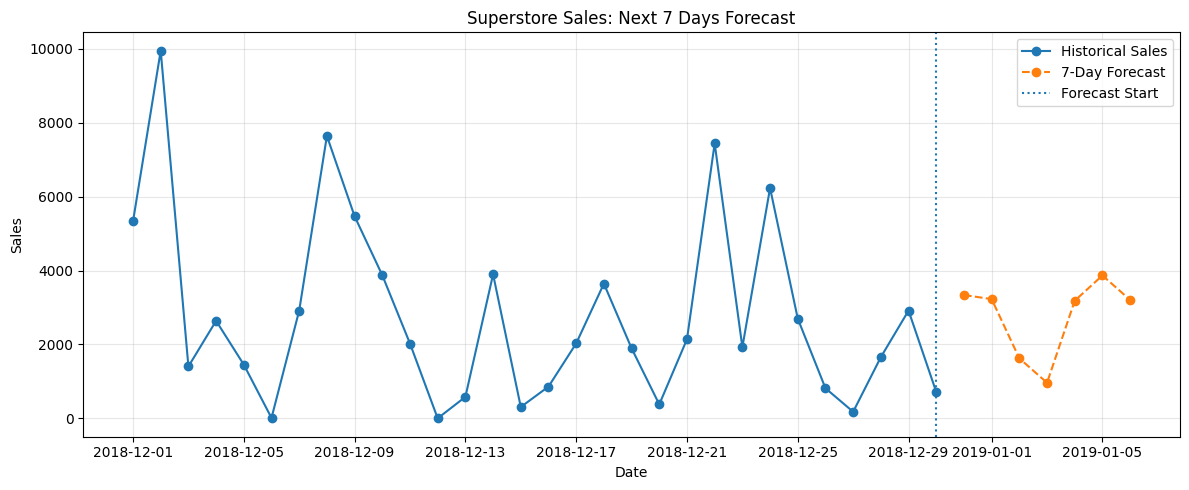

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

files = glob.glob("/content/*.csv")

if len(files) == 0:
    raise FileNotFoundError("No CSV file found in /content/")

file_path = files[0]
df = pd.read_csv(file_path)

print("File used:", file_path)
print("Dataset Shape:", df.shape)

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce")

df = df.dropna(subset=["Order Date", "Sales"])

daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .sort_index())

full_dates = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D")

daily_sales = daily_sales.reindex(
    full_dates,
    fill_value=0)

daily_sales.index.name = "Date"

print("\nTime Series Information")
print("-----------------------")
print("Start Date:", daily_sales.index.min().date())
print("End Date  :", daily_sales.index.max().date())
print("Number of Days:", len(daily_sales))

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales.index,
    daily_sales.values)

plt.title("Daily Superstore Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_days = 7

train = daily_sales.iloc[:-test_days]
test = daily_sales.iloc[-test_days:]

print("\nTraining Days:", len(train))
print("Testing Days :", len(test))

window = 7

moving_average_value = train.tail(window).mean()

ma_forecast = np.repeat(
    moving_average_value,
    test_days)

hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7)

hw_fit = hw_model.fit(
    optimized=True)

hw_forecast = hw_fit.forecast(test_days)

mae_ma = mean_absolute_error(
    test,
    ma_forecast)

rmse_ma = np.sqrt(
    mean_squared_error(
        test,
        ma_forecast))

mae_hw = mean_absolute_error(
    test,
    hw_forecast)

rmse_hw = np.sqrt(
    mean_squared_error(
        test,
        hw_forecast))

results = pd.DataFrame({
    "Model": [
        "7-Day Moving Average",
        "Holt-Winters"],
    "MAE": [
        mae_ma,
        mae_hw],
    "RMSE": [
        rmse_ma,
        rmse_hw]})

print("\n================ MODEL PERFORMANCE ================\n")
print(results.round(2).to_string(index=False))

best_model = results.loc[
    results["RMSE"].idxmin(),
    "Model"]

print("Best Forecasting Model:", best_model)

plt.figure(figsize=(12, 5))

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual Sales")

plt.plot(
    test.index,
    ma_forecast,
    marker="o",
    linestyle="--",
    label="Moving Average")

plt.plot(
    test.index,
    hw_forecast,
    marker="o",
    linestyle="--",
    label="Holt-Winters")

plt.title("Actual vs Forecasted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_model = ExponentialSmoothing(
    daily_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=7)

final_fit = final_model.fit(
    optimized=True)

future_forecast = final_fit.forecast(7)

forecast_dates = pd.date_range(
    start=daily_sales.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq="D")

forecast_df = pd.DataFrame({
    "Date": forecast_dates,
    "Forecasted Sales": future_forecast.values})

print("\n================ NEXT 7 DAYS FORECAST ================\n")
print(
    forecast_df.round(2).to_string(index=False))

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales.tail(30).index,
    daily_sales.tail(30).values,
    marker="o",
    label="Historical Sales")

plt.plot(
    forecast_dates,
    future_forecast.values,
    marker="o",
    linestyle="--",
    label="7-Day Forecast")

plt.axvline(
    daily_sales.index[-1],
    linestyle=":",
    label="Forecast Start")

plt.title("Superstore Sales: Next 7 Days Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()